<a href="https://colab.research.google.com/github/fatihonay/Neural-Variability-/blob/main/docs/source/Tutorials/Ar_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling Uncertainty: Generating a Model from EEG
We always talk about how neural signals are compliated and complex. When thinking about this dynamics fluctations, I sometimes get nervous. Suddenly a few questions emerge within my mind;

- Is there any generative model for these neural acitivity?
- If neural activity is stochastic, how could I perform meaningful analysis?
- What do the fluctuations in neural signals really represent physically, beyond just random noise?

If we find a model to represent hidden features of signal in a parametric manner, we would easily describe messy data with a simple model. And we will see that these models can also be generative source of neural activity. Let's begin !

### Autoregressive Modeling
Even if the noisy and fluctuating dynamics within EEG signals may seem irrelevant between its time instants, there can be temporal dependencies which causally propoate in time. One of the most known way of revaling these dependencies is auto-regressive (AR) modeling. I want to introdue a special technique of modeling which is named as Burg's method.

Burg’s method uses both forward and backward prediction errors. It does not rely on only backward or only forward iterations. Even though both directions are used in parameter estimation, the final auto-regressive (AR) model is causal.   So we still get a standard causal AR PSD.

### Burg Method: Forward and Backward Prediction Error

In the Burg method, we estimate the reflection coefficients $k_m$ at each stage $m$ by minimizing the sum of the forward and backward prediction error squares.

#### 1. Forward Prediction Error
The forward prediction error $f_m[n]$ at stage $m$ is defined as the error when predicting the current sample $x[n]$ using the previous $m$ samples:

$$f_m[n] = x[n] + \sum_{k=1}^{m} a_{m,k} x[n-k]$$

#### 2. Backward Prediction Error
The backward prediction error $b_m[n]$ represents the error when "postdicting" a past sample $x[n-m]$ using the subsequent $m$ samples:

$$b_m[n] = x[n-m] + \sum_{k=1}^{m} a_{m,k} x[n-m+k]$$

#### 3. Total Error Minimization (The Burg Criterion)
To find the optimal reflection coefficient $k_m$, we minimize the sum of the squares of both errors (averaged over the valid range of $N$ samples):

$$E_m = \sum_{n=m}^{N-1} \left( |f_m[n]|^2 + |b_m[n]|^2 \right)$$

By setting the derivative $\frac{\partial E_m}{\partial k_m} = 0$, we derive the formula for the reflection coefficient:

$$k_m = \frac{-2 \sum_{n=m}^{N-1} f_{m-1}[n] b_{m-1}[n-1]}{\sum_{n=m}^{N-1} \left( |f_{m-1}[n]|^2 + |b_{m-1}[n-1]|^2 \right)}$$

where $k_m$ represents the partial correlation between the forward and backward prediction errors at stage $m$.

```
Don't worry about the details of the math. Just get familiar with concept.
```

Let's being to model EEG signal using Burg's method.

For this purpose, I will use resting state EEG signals of Parkinson's disase subject from OpenNEURO with the following link.

https://openneuro.org/datasets/ds007020/versions/1.0.0

You can implement this demo with diferent data as well. You are completely free !

Extracting parameters from /content/drive/MyDrive/ds007020/sub-PD1991/ses-01/eeg/sub-PD1991_ses-01_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 139579  =      0.000 ...   279.158 secs...


/tmp/ipython-input-1160748145.py:9: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw       = mne.io.read_raw_brainvision(full_path, preload=True)


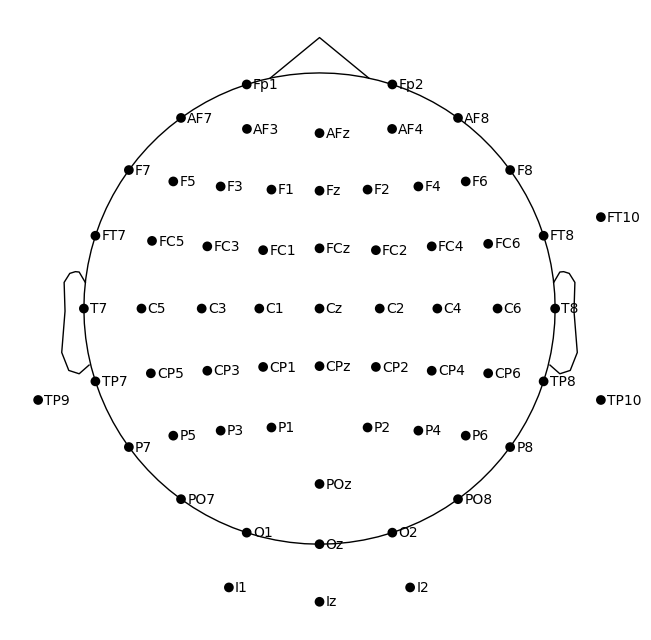

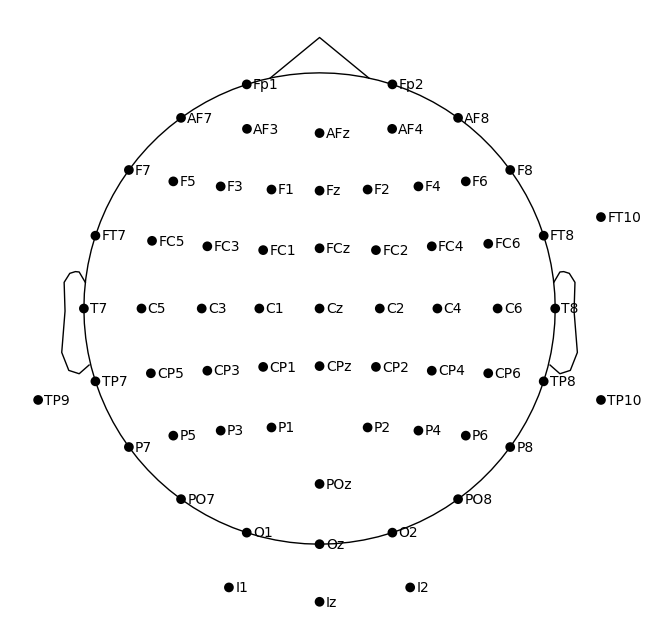

In [69]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load Data (you can edit for your own file)
base_path = '/content/drive/MyDrive/ds007020/sub-PD1991/ses-01/eeg/'
file_name = 'sub-PD1991_ses-01_task-rest_eeg.vhdr'
full_path = base_path + file_name
raw       = mne.io.read_raw_brainvision(full_path, preload=True)

# Let's visualize scalp montage
raw.plot_sensors(show_names=True)

We loaded EEG data and visualized the EEG cap. There are 64 channels in this dataset. We will use P4 channel to perform Burg's autoregressive modeling.  

```
The slow drifts and average values must be removed from signal before performing modeling. This will help us to avoid unstable model design.
```

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (3.302 s)

Optimal Order Selected by AKICc: 20


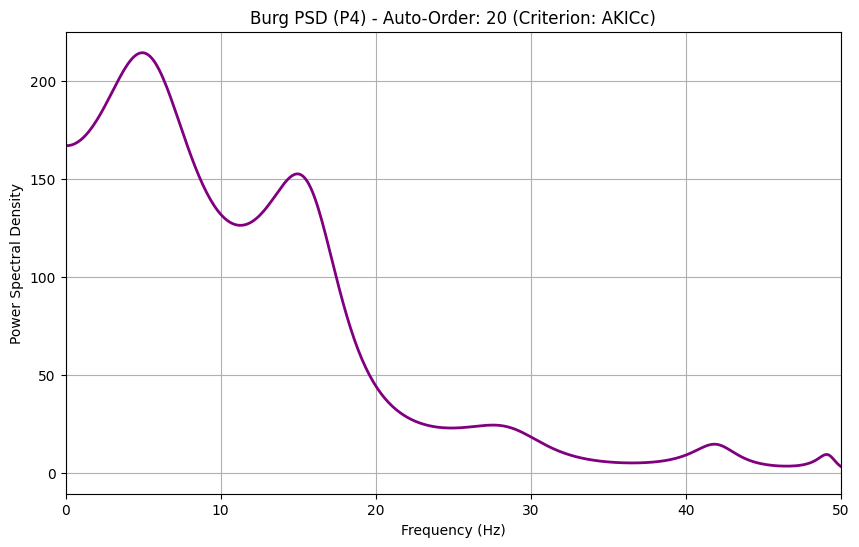

In [70]:
from spectrum import arburg, arma2psd
from scipy import signal

# --- 1. Prepare Data ---

#  Filter (0.5 - 40 Hz) P4 Channel
raw_P4  = raw.copy().pick_channels(['P4'])
raw_P4.filter(l_freq=1, h_freq=45.0, fir_design='firwin')
P4_data = raw_P4.get_data()[0]

# Detrend
P4_data_detrended = signal.detrend(P4_data, type='linear') * 1e6 # to microVolt

# Apply Burg AR with Automatic Order Selection (AKICc)
max_order = 20
AR, P, k = arburg(P4_data_detrended, max_order, criteria='AKICc')

# Calculate the actual order selected by the algorithm
selected_order = len(AR)
print(f"Optimal Order Selected by AKICc: {selected_order}")

# Compute PSD
PSD = arma2psd(AR, rho=P, sides='centerdc')

# Let's plot PSD of EEG signal
fs     = raw.info['sfreq']
freqs  = np.linspace(-fs/2, fs/2, len(PSD))

plt.figure(figsize=(10, 6))
plt.plot(freqs, PSD, color='purple', linewidth=2)
plt.title(f"Burg PSD (P4) - Auto-Order: {selected_order} (Criterion: AKICc)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.xlim(0, 50) # Just show 0 - 50 Hz
plt.grid(True)
plt.show()

## Stability Check
We succesfully estimated AR coefficients and used them to build PSD of the EEG signal. Now, we will check whether the estimated AR coeffients fair.

In order to understand this, we will build FIR filter using AR coefficients. If the model is good, filtering the data with these coefficients should result in white noise (the prediction error).

That's interesting hah ! Becaseu this filter will remove the predictable part within the signal. the remaining part is the error.  

LPC Order: 20
LPC Coefficients (a_0 ... a_p):
[  1.          -5.58551883  13.45905836 -18.55315932  17.35432164
 -13.81095387  10.79444788  -7.4517182    4.62374246  -2.98490659
   1.52562423  -0.70097402   0.75944131  -0.66933608   0.52623373
  -0.47849136   0.03076407   0.34153733  -0.17725218  -0.03127353
   0.02857678]


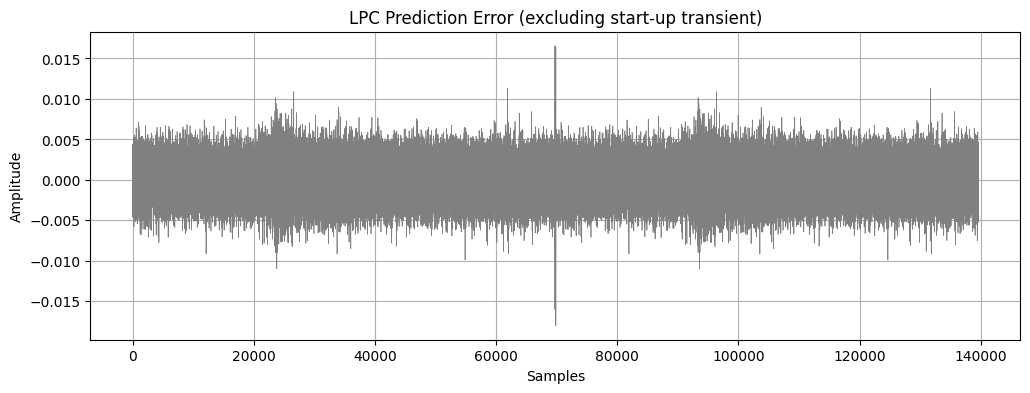

In [71]:

from scipy.signal import lfilter

# Get FIR filter: standard convention (A(z) filter), the first coefficient is always 1.0.
lpc_coeffs = np.concatenate(([1.0], np.real(AR)))

print(f"LPC Order: {len(AR)}")
print("LPC Coefficients (a_0 ... a_p):")
print(lpc_coeffs)

# The filter A(z) = 1 + a_1*z^-1 + ... removes the predictable part
prediction_error = lfilter(lpc_coeffs, [1.0], P4_data_detrended)

warmup_samples = len(AR)  # This is your order (e.g., 60)

valid_error = prediction_error[warmup_samples:]
valid_time  = np.arange(len(valid_error)) # Create new index for plotting

plt.figure(figsize=(12, 4))
plt.plot(valid_time, valid_error, color='gray', linewidth=0.5)
plt.title("LPC Prediction Error (excluding start-up transient)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()



As you can see, we obtained white noise as a resulf of filtering. This filter is also called as "whitening filter".  Now, we will go one more step. We calculate autocorrelation of the error signal. The classical white noise has a big peak at zero-lag correlation. This peak disappear as correlation calculated at different time lags.

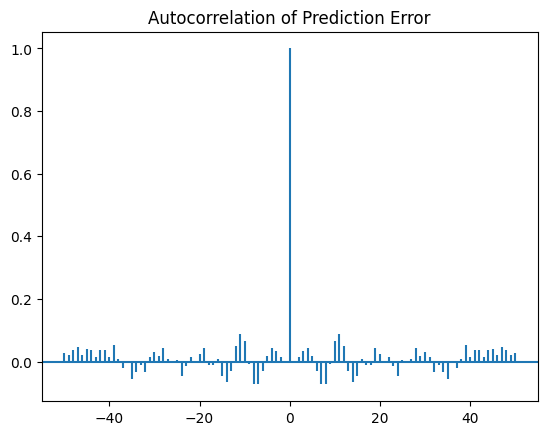

In [72]:
# Check if the residual is truly white noise
plt.acorr(valid_error, maxlags=50)
plt.title("Autocorrelation of Prediction Error")
plt.show()

We obtained a really beautiful autocorrelation which represent white noise dynamics. This proves, we build a stable autoregressive model and we can trust estimated PSD of the EEG signal.

```
Trust me, I am an engineer !
```

I guess some people may not be convinced with our beautiful stable model. We can also check the stabiltiy by observing poles of the filter in z-plane. If our poles are inside unit circle, then we can be 100% sure the model is stable. Let's check the poles of the model.

Model Stable? : True
Max Pole Magnitude: 0.9903


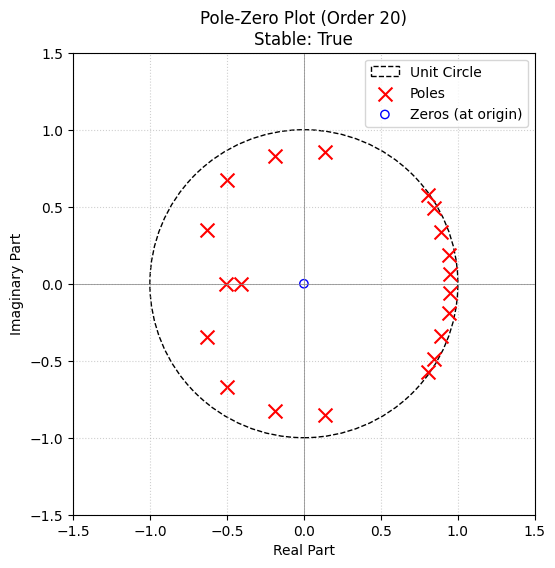

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Calculate Poles
# The poles are the roots of the denominator polynomial [1, a1, a2, ...]
coeffs = np.concatenate(([1], AR))
poles  = np.roots(coeffs)

# Check Stability
is_stable = np.all(np.abs(poles) < 1)
print(f"Model Stable? : {is_stable}")
print(f"Max Pole Magnitude: {np.max(np.abs(poles)):.4f}")

# Plot Z-Plane
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the Unit Circle
unit_circle = Circle((0,0), 1, color='black', fill=False, linestyle='--', label='Unit Circle')
ax.add_patch(unit_circle)

# Plot the poles
ax.scatter(np.real(poles), np.imag(poles), marker='x', color='red', s=100, label='Poles')

# Plot zeros
ax.scatter(0, 0, marker='o', facecolors='none', edgecolors='blue', label='Zeros (at origin)')

# Formatting
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title(f"Pole-Zero Plot (Order {len(AR)})\nStable: {is_stable}")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Analysis vs. Synthesis

Now that we have computed the AR coefficients using Burg's method and verified the model's stability. But we did not finish yet. We can interpret this model through two distinct but connected lenses: **Analysis** and **Synthesis**.

### 1. The Analysis Property (The Inverse Filter)
The Analysis step involves estimating the model parameters to describe the data. Mathematically, this corresponds to applying the **Inverse Filter** (often denoted as $A(z)$) to our original EEG signal. The goal is to subtract the predictable parts of the signal based on past samples.

$$e[n] = x[n] + \sum_{k=1}^{p} a_k x[n-k]$$
    
Here, $x[n]$ is our EEG data and $e[n]$ is the prediction error.

---

### 2. The Synthesis Property
The Synthesis step is the reverse process. Once we have the model coefficients, we can treat the AR model as a generative system filter ($H(z)$). If we feed pure white noise (with variance $P$) into this system, it shapes that noise into a signal that is spectrally identical to our original EEG.

* **Mathematical Operation:**
    $$H(z) = \frac{1}{A(z)} = \frac{1}{1 + \sum_{k=1}^{p} a_k z^{-k}}$$


Now, let's generate EEG signal using our stable model.

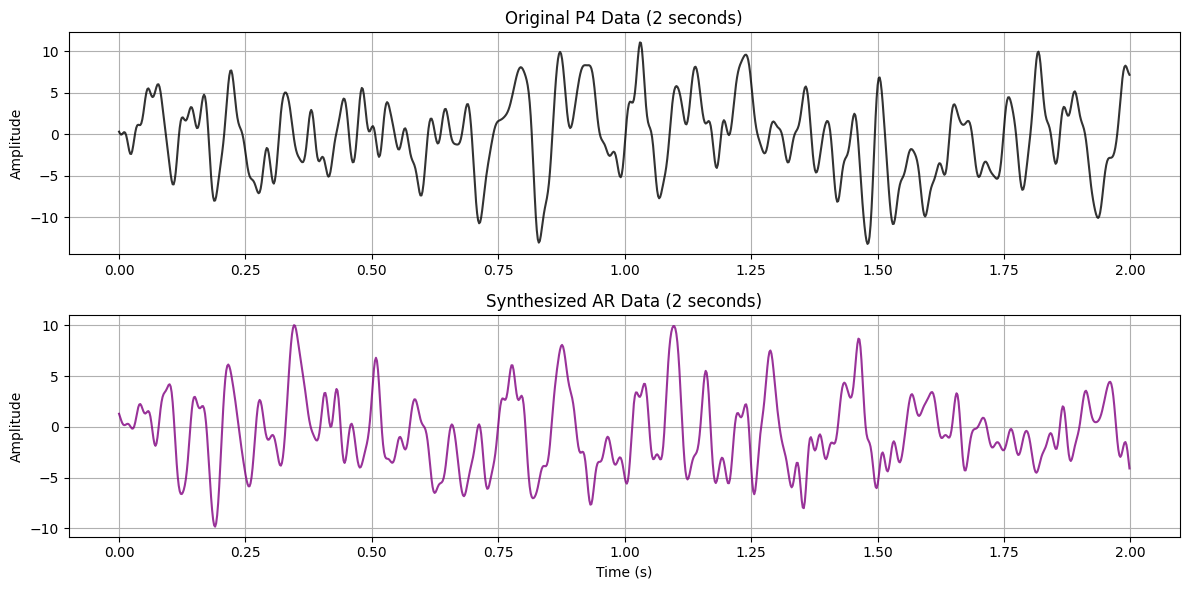

In [74]:
from scipy.signal import lfilter

#  Synthesis Filter
gain       = np.sqrt(P) # P is the variance of the error, so gain is sqrt(P).
lpc_coeffs = np.concatenate(([1.0], np.real(AR)))

# Generate White Noise
n_samples   = len(P4_data_detrended)
white_noise = np.random.normal(0, 1, n_samples)

# Filter the white noise to shape it into EEG:  b = [gain], a = lpc_coeffs
synthesized_eeg = lfilter([gain], lpc_coeffs, white_noise)

# Plot Comparison
zoom_sec        = 2
samples_to_show = int(zoom_sec * fs)
start_idx       = 1000 # start point
time_axis       = np.arange(samples_to_show) / fs

plt.figure(figsize=(12, 6))

# Plot Original
plt.subplot(2, 1, 1)
plt.plot(time_axis, P4_data_detrended[start_idx:start_idx+samples_to_show], color='black', alpha=0.8)
plt.title("Original P4 Data (2 seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot Synthetic
plt.subplot(2, 1, 2)
plt.plot(time_axis, synthesized_eeg[start_idx:start_idx+samples_to_show], color='purple', alpha=0.8)
plt.title("Synthesized AR Data (2 seconds)")
plt.ylabel("Amplitude")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

Look at the generated data. You can generate tons of EEG data using the our model.

The white noise is transformed into EEG dynamics. Even if the neural data is non-stationary, we found a way of modeling is using AR modeling strategy.